In [91]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ian\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ian\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ian\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [63]:
df = pd.read_csv("judge-1377884607_tweet_product_company.csv",encoding='ISO-8859-1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [58]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [118]:
df = df.rename(columns={'emotion_in_tweet_is_directed_at': 'receiver_end'})

In [120]:
#What are value counts of 'receiver_end'column
df['receiver_end'].value_counts()

iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: receiver_end, dtype: int64

In [109]:
# Preprocess tweet text for NLP analysis:
# Lowercases all words
# Removes links, mentions, hashtags, punctuation (but strips out numbers too)
# Strips excess whitespace
# Filters out common stopwords
# Outputs cleaned tweet string


def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|@\S+|#\S+|[^a-zA-Z\s]", "", text)  
    text = re.sub(r"\s+", " ", text).strip()
    stop_words = set(stopwords.words('english'))
    return " ".join([word for word in text.split() if word not in stop_words])



In [110]:
# Apply text cleaning to each tweet and store in new column
df['clean_tweet'] = df['tweet_text'].apply(clean_tweet)
df[['tweet_text', 'clean_tweet']].head()

,tweet_text,clean_tweet
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting dead need upgrade plugin...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,wait also sale
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...


In [111]:
# Frequent words across tweets

from collections import Counter
top_words = Counter(" ".join(df['clean_tweet']).split()).most_common(20)
print(top_words)




[('link', 4284), ('rt', 2959), ('ipad', 2310), ('google', 2023), ('apple', 1738), ('store', 1465), ('iphone', 1250), ('new', 1088), ('austin', 842), ('app', 789), ('amp', 724), ('launch', 643), ('social', 623), ('popup', 597), ('today', 563), ('circles', 529), ('sxsw', 490), ('network', 462), ('android', 435), ('via', 435)]


In [112]:
# Define a mapping dictionary to rename emotion labels with simpler names and emojis

emotion_map = {
    'Positive emotion': 'Positive 😊',
    'Negative emotion': 'Negative 😠',
    'No emotion toward brand or product': 'Neutral 😐'
}

# Apply the emotion label mapping to create a new column with cleaned and user-friendly names

df['emotion_cleaned'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].map(emotion_map)


# Display the newly created column

df["emotion_cleaned"]



0       Negative 😠
1       Positive 😊
2       Positive 😊
3       Negative 😠
4       Positive 😊
           ...    
9088    Positive 😊
9089     Neutral 😐
9090     Neutral 😐
9091     Neutral 😐
9092     Neutral 😐
Name: emotion_cleaned, Length: 9093, dtype: object

In [113]:
# Preview the first few rows of cleaned tweets alongside their corresponding emotion labels

df[['clean_tweet', 'emotion_cleaned']].head()



,clean_tweet,emotion_cleaned
0,g iphone hrs tweeting dead need upgrade plugin...,Negative 😠
1,know awesome ipadiphone app youll likely appre...,Positive 😊
2,wait also sale,Positive 😊
3,hope years festival isnt crashy years iphone app,Negative 😠
4,great stuff fri marissa mayer google tim oreil...,Positive 😊


### Tokenization

In [114]:
# Apply word_tokenize to each cleaned tweet

df['tokens'] = df['clean_tweet'].apply(word_tokenize)

df[['clean_tweet', 'tokens']].head()



,clean_tweet,tokens
0,g iphone hrs tweeting dead need upgrade plugin...,"[g, iphone, hrs, tweeting, dead, need, upgrade..."
1,know awesome ipadiphone app youll likely appre...,"[know, awesome, ipadiphone, app, youll, likely..."
2,wait also sale,"[wait, also, sale]"
3,hope years festival isnt crashy years iphone app,"[hope, years, festival, isnt, crashy, years, i..."
4,great stuff fri marissa mayer google tim oreil...,"[great, stuff, fri, marissa, mayer, google, ti..."


### Lemmatization

In [115]:
lemmatizer = WordNetLemmatizer()

df['lemmatized_tweet'] = df['clean_tweet'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df['lemmatized_tweet']


0       g iphone hr tweeting dead need upgrade plugin ...
1       know awesome ipadiphone app youll likely appre...
2                                          wait also sale
3          hope year festival isnt crashy year iphone app
4       great stuff fri marissa mayer google tim oreil...
                              ...                        
9088                                 ipad everywhere link
9089    wave buzz rt interrupt regularly scheduled gee...
9090    google zeiger physician never reported potenti...
9091    verizon iphone customer complained time fell b...
9092                    rt google test checkin offer link
Name: lemmatized_tweet, Length: 9093, dtype: object

In [116]:
df[['clean_tweet', 'lemmatized_tweet']].head()


,clean_tweet,lemmatized_tweet
0,g iphone hrs tweeting dead need upgrade plugin...,g iphone hr tweeting dead need upgrade plugin ...
1,know awesome ipadiphone app youll likely appre...,know awesome ipadiphone app youll likely appre...
2,wait also sale,wait also sale
3,hope years festival isnt crashy years iphone app,hope year festival isnt crashy year iphone app
4,great stuff fri marissa mayer google tim oreil...,great stuff fri marissa mayer google tim oreil...


In [152]:
#Combine Regular Columns into One DataFrame

df_features = df[['tweet_text','clean_tweet', 'emotion_cleaned', 'tokens', 'lemmatized_tweet','receiver_end']]
df_features.head()

,tweet_text,clean_tweet,emotion_cleaned,tokens,lemmatized_tweet,receiver_end
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting dead need upgrade plugin...,Negative 😠,"[g, iphone, hrs, tweeting, dead, need, upgrade...",g iphone hr tweeting dead need upgrade plugin ...,Apple
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...,Positive 😊,"[know, awesome, ipadiphone, app, youll, likely...",know awesome ipadiphone app youll likely appre...,Apple
2,@swonderlin Can not wait for #iPad 2 also. The...,wait also sale,Positive 😊,"[wait, also, sale]",wait also sale,Apple
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone app,Negative 😠,"[hope, years, festival, isnt, crashy, years, i...",hope year festival isnt crashy year iphone app,Apple
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...,Positive 😊,"[great, stuff, fri, marissa, mayer, google, ti...",great stuff fri marissa mayer google tim oreil...,Google


### Vectorize

In [153]:


# Initialize the vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform your lemmatized tweets into a sparse matrix
X = vectorizer.fit_transform(df['lemmatized_tweet'])




In [154]:
# checking the distribution of emotions
percentage = df['emotion_cleaned'].value_counts(normalize=True)
print(percentage * 100)

Neutral 😐     60.299877
Positive 😊    33.322144
Negative 😠     6.377979
Name: emotion_cleaned, dtype: float64


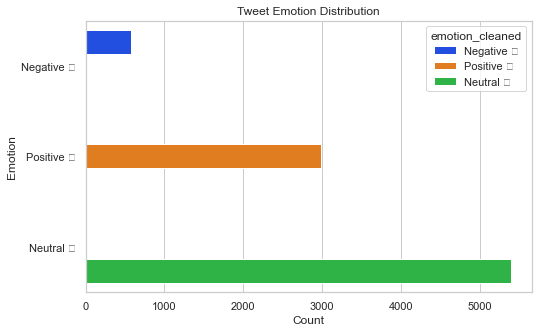

In [155]:
sns.set_theme(style="whitegrid")

# Initialize the plot canvas
plt.figure(figsize=(8,5))

# Create the bar plot (without the invalid legend argument)
sns.countplot(data=df_features, y='emotion_cleaned', hue='emotion_cleaned', palette='bright')

# Set the title and axis labels
plt.title("Tweet Emotion Distribution")
plt.xlabel("Count")
plt.ylabel("Emotion")

# Show the plot
plt.show()




In [156]:
# Count combinations of recipient and emotion
df.groupby('receiver_end')['emotion_cleaned'].value_counts().unstack().fillna(0)




emotion_cleaned,Negative 😠,Neutral 😐,Positive 😊
receiver_end,,,
Android,16,2,141
Apple,388,65,1949
Google,115,24,582
Unknown,51,5298,306


In [157]:
df['receiver_end'].unique()



array(['Apple', 'Google', 'Unknown', 'Android'], dtype=object)

In [161]:
# Replace app-specific labels with their broader categories
df['receiver_end'] = df['receiver_end'].replace({
    'iPad or iPhone App': 'Apple',
    'Other Apple product or service': 'Apple',
    'Other Google product or service': 'Google',
    'Android App': 'Android',
    'iPhone': 'Apple',
    'iPad': 'Apple'
})
df['receiver_end'] = df['receiver_end'].fillna('Unknown')



In [162]:
emotion_summary = df.groupby('receiver_end')['emotion_cleaned'].value_counts().unstack().fillna(0).reset_index()
df_features = df_features.merge(emotion_summary, on='receiver_end', how='left')
df_features.head()



,tweet_text,clean_tweet,emotion_cleaned,tokens,lemmatized_tweet,receiver_end,Negative 😠,Neutral 😐,Positive 😊
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting dead need upgrade plugin...,Negative 😠,"[g, iphone, hrs, tweeting, dead, need, upgrade...",g iphone hr tweeting dead need upgrade plugin ...,Apple,388,65,1949
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...,Positive 😊,"[know, awesome, ipadiphone, app, youll, likely...",know awesome ipadiphone app youll likely appre...,Apple,388,65,1949
2,@swonderlin Can not wait for #iPad 2 also. The...,wait also sale,Positive 😊,"[wait, also, sale]",wait also sale,Apple,388,65,1949
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone app,Negative 😠,"[hope, years, festival, isnt, crashy, years, i...",hope year festival isnt crashy year iphone app,Apple,388,65,1949
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...,Positive 😊,"[great, stuff, fri, marissa, mayer, google, ti...",great stuff fri marissa mayer google tim oreil...,Google,115,24,582
